In [147]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
import openai
from processing import (
    generate_comments,
    df_character_cleaning,
    get_comments_sentiment,
    comparison_table,
    get_movie_entities,
    TOTAL_SUMMARIZER,
    create_movie_info,
    generate_summary_marketing,
    process_comments_in_batches,
)
from config import movies
import re
from visualization import sentiment_viz, emotion_viz, display_comments_by_topic
from app import extract_youtube_id, extract_imdb_id, summarize_comments
load_dotenv()
import matplotlib.pyplot as plt
import seaborn as sns
from agentic import generate_marketing_suggestions, evaluate_marketing_suggestions, review_marketing_suggestions, improve_marketing_suggestions

In [148]:
youtube_ref = "https://www.youtube.com/watch?v=n9xhJrPXop4"
video_id = extract_youtube_id(youtube_ref)

imdb_ref = "https://www.imdb.com/title/tt1160419/"
movie_id = extract_imdb_id(imdb_ref)

In [149]:
comments = generate_comments(video_id, os.getenv("YT_KEY"), max_comments=1000)
comments = df_character_cleaning(comments)
#all_scores = get_comments_sentiment(st.session_state.comments)
#table = comparison_table(all_scores, movie_id, movies)

In [150]:
entities_df = get_movie_entities(movie_id)

In [151]:
movie_info = create_movie_info(movie_id, entities_df)

In [152]:
topics = summarize_comments(comments, movie_info)

In [153]:
topics

['1. Visual Excellence: Commenters frequently praised the films stunning cinematography and visual effects, calling it a cinematic masterpiece that showcases an extraordinary visual experience.  ',
 '2. Music and Sound Design: The score, particularly Hans Zimmers contributions, received high acclaim, with many noting how the soundtrack elevated the emotional impact and overall atmosphere of the film.  ',
 '3. Compelling Storytelling: Some viewers expressed admiration for the films narrative, considering it emotionally impactful and engaging, with comparisons to classic stories, contributing to a strong sense of intrigue about the characters and their journeys.  ',
 '4. Strong Performances: The acting, especially Timothée Chalamets and Zendyas portrayals, was highlighted positively, with many viewers feeling that the cast brought depth and authenticity to their roles.  ',
 '5. Cultivated Interest in Source Material: Several commenters indicated that their viewing experience sparked a de

In [154]:
comments_topics_df = process_comments_in_batches(comments, topics, batch_size=50)

matching in progressmatching in progress

matching in progress
matching in progress
matching in progress
matching in progress
matching in progress
matching in progress
matching in progress
matching in progress
matching in progress
matching in progress
matching done
matching in progress
matching done
matching in progress
matching done
matching in progress
matching done
matching in progress
matching done
matching in progress
matching done
matching in progress
matching done
matching in progress
matching done
matching in progress
matching done
matching done
matching done
matching done
Error during matching: Invalid \escape: line 10 column 13 (char 1582)
text: ['VAMOOOOOOOOOOOOOO', 'Do you often dream of wet dream and wake up wet in your dream?', 'What You Mean U Only Are??', 'This movie gave me thé sensations of 80s  Richard Corben , Bilal ,Siudmak drowings . Images and sounds in this movie get me into the Dreams i love . It s wonderfull !', 'This movie gave me thé sensations of 80s  Richa

In [155]:
def display_comments_by_topic(df):
    df = df.fillna(0)
    # Sum the counts across rows to get total counts for each topic
    df_counts = df.sum(axis=0).reset_index()
    df_counts.columns = ["Topic", "Count"]

    # Ensure all possible topics (1-10) are included by filling in missing topics with a count of 0
    all_topics = [str(i) for i in range(1, 11)]  # Topics numbered 1-10 as strings
    df_counts = df_counts.set_index("Topic")
    df_counts = df_counts.reindex(all_topics, fill_value=0).reset_index()

    # Convert 'Topic' column back to integer if needed
    df_counts["Topic"] = df_counts["Topic"].astype(int)

    # Plotting
    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(18, 10))

    # Define your color palette
    muted_green = "#6dbf67"
    coolwarm_red = "#d73027"
    palette = [muted_green] * 5 + [
        coolwarm_red
    ] * 5  # First 5 bars in muted_green, next 5 in coolwarm_red

    # Create the count plot
    ax = sns.barplot(data=df_counts, x="Topic", y="Count", palette=palette)

    # Set plot background color
    plt.gcf().set_facecolor(".1")  # Set the background of the figure
    ax.set_facecolor(".1")  # Set the background of the axes

    # Set title and labels with a lighter color for visibility
    plt.title("Number of Comments by Topic", color="white")
    plt.xlabel("Topic", color="white")
    plt.ylabel("Count of Comments", color="white")

    # Change the color of the ticks and tick labels
    plt.xticks(color="white")
    plt.yticks(color="white")

    # Change the color of the axes' spines
    for spine in ax.spines.values():
        spine.set_edgecolor("white")

    # Adding the count above each bar
    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            xytext=(0, 5),
            textcoords="offset points",
        )

    # Calculate total counts for the first 5 and next 5 topics
    first_5_total = df_counts[df_counts["Topic"].isin(df_counts["Topic"].unique()[:5])][
        "Count"
    ].sum()
    next_5_total = df_counts[df_counts["Topic"].isin(df_counts["Topic"].unique()[5:])][
        "Count"
    ].sum()

    # Get current axes and calculate percentages
    ax = plt.gca()
    positive_perc = first_5_total / (first_5_total + next_5_total) * 100
    negative_perc = next_5_total / (first_5_total + next_5_total) * 100

    # Infographic text
    plt.text(
        7.8,
        ax.get_ylim()[1] * 0.92,
        f"POS : {positive_perc:.4g}%\nNEG : {negative_perc:.4g}%",
        color="white",
        fontweight="bold",
    )

    # Create the plot
    plt.show()

In [156]:
%matplotlib inline

/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_48474/1641174399.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_counts, x="Topic", y="Count", palette=palette)


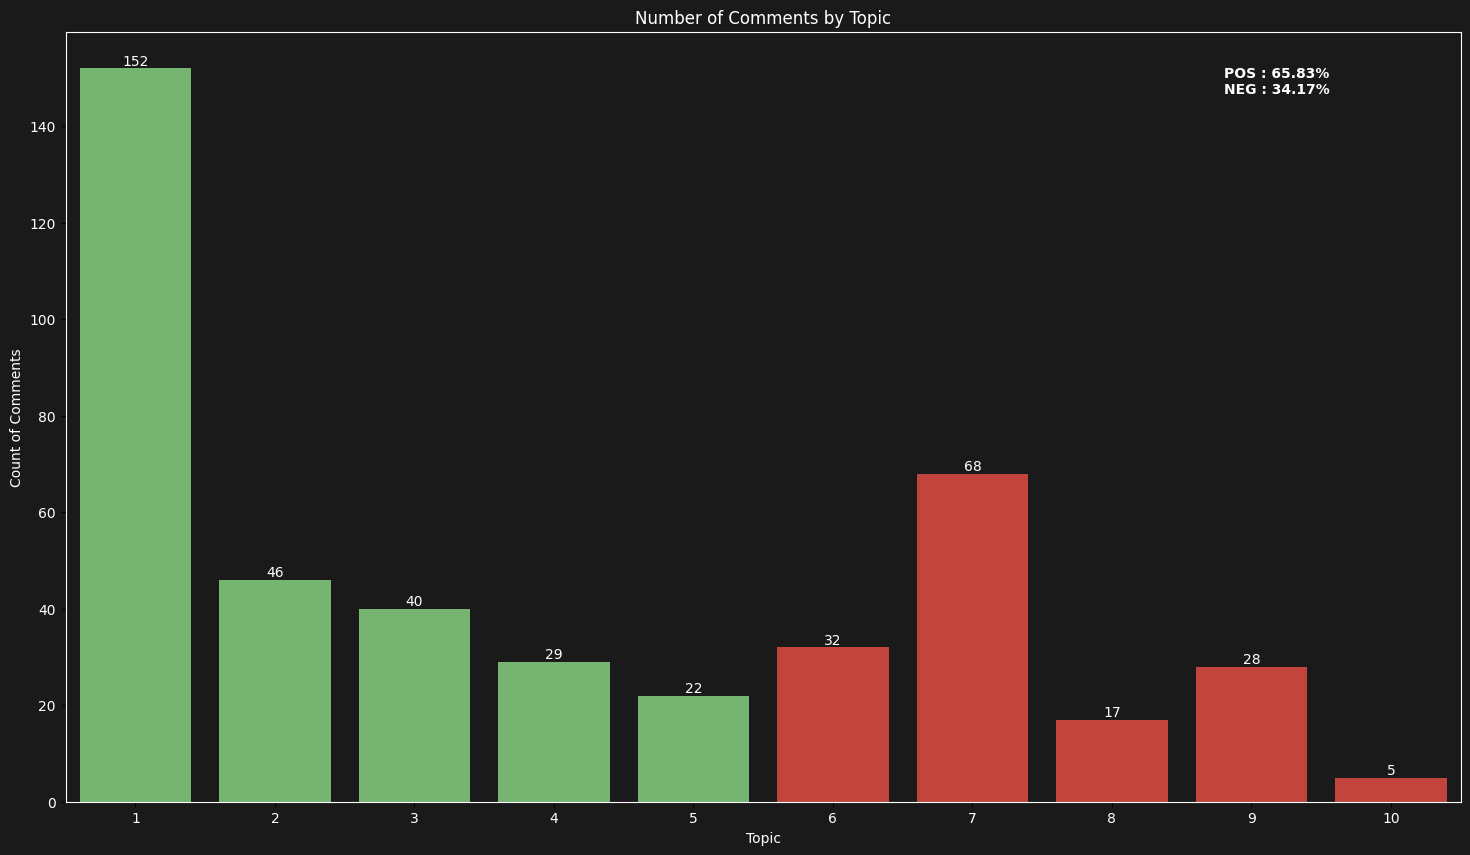

In [157]:
display_comments_by_topic(comments_topics_df)

## Marketing

In [200]:
class ChatGPT:
    def __init__(self, model="gpt-4o-mini", system_message=None):
        self.model = model
        self.client = openai.OpenAI()
        self.default_system_message = {"role": "system", "content": system_message}
        self.messages = [self.default_system_message]

    def add_user_message(self, message, reset_chat=False):
        if reset_chat:
            self.messages = [self.default_system_message]
        self.messages.append({"role": "user", "content": message})

    def get_response(self):
        completion = self.client.chat.completions.create(
            model=self.model, messages=self.messages
        )
        assistant_message = completion.choices[0].message.content
        self.messages.append({"role": "assistant", "content": assistant_message})
        return assistant_message


In [204]:
def generate_suggestions(topics, movie_info):
    analyst_prompt = f"""
    Here is information on the given film of interest: {movie_info}
    Here are the general topics people are discussing related to this film: \n {topics}
    Given the topics that users are speaking about your movie trailer, output 5 of the most relevant marketing suggestions you can concoct to help promote the film in list-format, with details for being included in application to this specific film.
    Please lend creative and specific suggestions to help market this film.
    Please ensure each suggestion is unique; do not repeat similar suggestions multiple times.
    Start directly with the list, do not include other text, and be concise (yet detailed) in your suggestions.
    """
    analyst = ChatGPT(
        system_message="You are a senior marketing analyst at a big movie production company. You are tasked with creating a set of marketing actions for a new movie, based on the topics that users are discussing. \
            You are in competition with another analyst for this task, one of you will be fired and the other promoted. For each reply, take a deep breath and think step by step."                
    )
    analyst.add_user_message(analyst_prompt)
    summarized_chunk = analyst.get_response()
    return summarized_chunk, analyst

In [240]:
critic = ChatGPT(
    system_message="You are a senior marketing associate at a big movie production company. You are tasked with guiding two junior analysts to provide optimal marketing actions for a new movie, based on the topics that users are discussing. \
    For each reply, take a deep breath and think step by step. I will tip you $100."
)
def review_suggestions(
    topics, movie_info, marketing_suggestions, critic, first_pass=False, final=False
):
    suffix = f"""
    Please review each suggestion and provide feedback on whether it is an appropriate marketing action considering feasibility, cost-effectiveness, general marketing science as well as public relations and social media knowledge. This feedback will be vital to improve our marketing strategy.
    Be extremely severe in your judgment, your career depends on it. If a suggestion is not relevant enough, you will be held responsible for not catching it and fired.
    At the beginning of your review, make sure to provide a clear ranking of the 10 suggestions, from best to worst.
    Conclude with a general comment on the overall quality of the suggestions, and what specific areas need improvement.
    Do not include meta information in your reply.
    """

    if first_pass==True:
        critic_prompt = f"""
        Here is information on the given film of interest: {movie_info}
        Here are the general topics people are discussing related to this film: \n {topics}
        Given the topics that users are speaking about your movie trailer, the two analysts have come up with the following marketing suggestions, in no particular order: {marketing_suggestions}
        {suffix}
        """
    else:
        critic_prompt = f"""
        Given your feedback, the two analysts have revised the marketing suggestions for the film. Here are the updated suggestions: {marketing_suggestions}
        {suffix}"""
    if final == True:
        critic_prompt = f"""
        Given your feedback, the two analysts have revised the marketing suggestions for the film. Here are the final updated suggestions: {marketing_suggestions}
        Return the top 5 best unique suggestions, in list format, with no explanation or justification.
        Start directly with the list and do not include other text."""

    critic.add_user_message(critic_prompt)
    critic_message = critic.get_response()
    return critic_message, critic

In [225]:
def improve_suggestions(analyst, critic_message, competing_suggestions):
    analyst_prompt = f"""
        The other analyst has provided these suggestions: {competing_suggestions}
        Given all suggestions, an advanced reviewer from your team has provided the following ranking and explanation : {critic_message}
        Please review the feedback and provide a new set of 5 suggestions. You can keep some of the old ones if they are good enough, but you must provide at least 2 new suggestions which were in neither of the previous lists.
        Moreover, you must improve the quality of the suggestions based on the feedback provided by the advanced reviewer.
        Output the revised suggestions in list-format, with details for each suggestion. Start directly with the list and do not include other text.
    """
    analyst.add_user_message(analyst_prompt)
    evaluations = analyst.get_response()
    return evaluations, analyst

#### Marketing #1

In [244]:
marketing_suggestions1, analyst1 = generate_marketing_suggestions(topics, movie_info)
print(marketing_suggestions1)

1. **Visual Storytelling Campaign**: Create a series of visually stunning posters and short video teasers that highlight the film's breathtaking cinematography and special effects. Use behind-the-scenes footage showcasing the work of cinematographer Greig Fraser and the visual effects team, emphasizing the film as a "cinematic masterpiece." Leverage social media platforms like Instagram and TikTok to reach younger audiences through engaging visuals.

2. **Music Experience Initiative**: Launch a dedicated audio campaign featuring Hans Zimmer’s score. Collaborate with music streaming platforms (e.g., Spotify, Apple Music) to create curated playlists inspired by the movie, including behind-the-scenes commentary where Zimmer discusses his creative process. Schedule virtual listening events where fans can join and experience the soundtrack while discussing the film's emotional impact.

3. **Character Deep-Dive Series**: Develop a web series that explores the characters' journeys, particular

In [245]:
marketing_suggestions2, analyst2 = generate_marketing_suggestions(topics, movie_info)
print(marketing_suggestions2)

1. **Behind-the-Scenes Visual Showcase**: Create a series of eye-catching behind-the-scenes videos that highlight the film's stunning cinematography and visual effects. Feature interviews with the cinematographer, Greig Fraser, and the director, Denis Villeneuve, discussing their creative vision and techniques used in the film. This will enhance viewer appreciation for the visual excellence lauded by the audience.

2. **Hans Zimmer Music Experience Event**: Organize live events or listening parties in major cities where fans can experience Hans Zimmer's score in an immersive setting, possibly with a screening of selected visuals from the film. Invite fans to discuss the music's emotional impact and how it complements the storytelling, tapping into the positive reception of the film's audio components.

3. **Interactive Storytelling Campaign**: Launch an interactive digital narrative that allows users to explore character backstories and plot lines from Frank Herbert's original books. B

In [248]:
all_suggestions1 = marketing_suggestions1 + marketing_suggestions2
critic_message1, critic = review_suggestions(
    topics, movie_info, all_suggestions1, critic, first_pass=True)
print(critic_message1)

1. **Visual Storytelling Campaign**
2. **Music Experience Initiative**
3. **Behind-the-Scenes Visual Showcase**
4. **Character Deep-Dive Series**
5. **Virtual Q&A with the Cast**
6. **Hans Zimmer Music Experience Event**
7. **Animated Narrative Recaps**
8. **Book Club Engagement**
9. **Interactive Storytelling Campaign**
10. **Addressing Pacing and Narrative Critiques**

**Feedback on Suggestions**:

1. **Visual Storytelling Campaign**: This is an outstanding initiative to visually showcase the film’s most praised element. The use of visually appealing posters and trailers can significantly drive excitement and engagement on social media, especially among younger demographics who heavily utilize platforms like Instagram and TikTok. 

2. **Music Experience Initiative**: Leveraging Hans Zimmer's score through collaborations with music streaming services is a strategic move. It taps into the emotional impact of the film's music and creates a unique experience for fans. Virtual listening e

#### Marketing #2

In [249]:
revised_suggestions1, analyst_1 = improve_suggestions(analyst1, critic_message1, marketing_suggestions2)
print(revised_suggestions1)

1. **Visual Storytelling Campaign**: Create a vibrant and immersive promotional campaign that showcases the film’s stunning visuals. Utilize high-quality posters, animated GIFs, and short video clips across social media platforms, with a particular focus on Instagram and TikTok. Collaborate with visual influencers to share their interpretations of the cinematic scenes, potentially creating a viral challenge that encourages fans to recreate iconic moments from the film.

2. **Hans Zimmer Immersive Experience Project**: Instead of physical events, develop an immersive virtual reality experience where fans can explore the film’s universe while listening to Hans Zimmer’s score. This could be delivered through VR platforms or interactive websites, allowing viewers to engage with the film's score while visualizing key scenes and themes. This initiative draws on the emotional impact of the music while ensuring accessibility for all fans.

3. **Character and Lore Discovery Series**: Launch a d

In [250]:
revised_suggestions2, analyst_2 = improve_suggestions(analyst1, critic_message1, marketing_suggestions1)
print(revised_suggestions2)

1. **Visual Storytelling Campaign**: Launch a visually captivating campaign that includes striking posters, animated digital content, and dynamic video teasers emphasizing the film’s stunning cinematography. Encourage fan interaction by hosting a “Fan Art Challenge” on social media platforms such as Instagram and TikTok, where users can submit their artistic interpretations of scenes or characters. This will enhance engagement and drive buzz among younger audiences.

2. **Hans Zimmer Soundscape Experience**: Develop a comprehensive multimedia experience featuring Hans Zimmer's score coupled with thematic visuals from the film. This could include an interactive online listening experience that allows fans to explore different score pieces while visualizing corresponding scenes from the film. Add an educational component where Zimmer explains how specific tracks align with character arcs and emotional moments, further enhancing the audience's connection to the film.

3. **In-Depth Charac

In [251]:
all_suggestions2 = revised_suggestions1 + revised_suggestions2
critic_message2, critic = review_suggestions(_, _, all_suggestions2, critic)

#### Marketing #3

In [252]:
final_suggestions1, analyst_1 = improve_suggestions(analyst1, critic_message2, marketing_suggestions2)
print(final_suggestions1)

1. **Enhanced Visual Storytelling Campaign**: Expand on the previous visual storytelling efforts by creating a mini-documentary series that dives into the film’s visual effects and art design. Each episode can explore specific scenes, illustrating the transformation from initial concept art to the final product. Share these videos on YouTube and social media platforms, encouraging viewer interaction through comments and sharing experiences about their favorite visuals.

2. **Curated Hans Zimmer Soundtrack Experience**: Instead of a single event, develop an ongoing content series that curates tracks from Hans Zimmer’s score intertwined with thematic visuals of the film. Create playlists that reflect different characters' journeys and emotional arcs, supported by commentary from Zimmer and insights on how the score interacts with key scenes. Promote this content through collaborations with music influencers or podcasts that focus on film scores.

3. **Dynamic Character Exploration on Soc

In [253]:
final_suggestions2, analyst_2 = improve_suggestions(analyst2, critic_message2, marketing_suggestions1)
print(final_suggestions2)

1. **Visual Storytelling Campaign**: Develop a multifaceted visual campaign utilizing stunning posters, animated GIFs, and short video teasers that showcase the film’s breathtaking cinematography. Incorporate behind-the-scenes footage of Greig Fraser’s techniques and interviews with Denis Villeneuve to provide insights into the visual storytelling approach. Launch interactive fan art challenges on social media platforms like Instagram and TikTok, where fans create and share their interpretations of scenes, tapping into the audience's admiration for visual excellence and encouraging community engagement.

2. **Hans Zimmer Soundscape Experience**: Build on the previous music initiative by organizing a series of virtual and in-person immersive listening events where audiences can experience Hans Zimmer's score while interacting with visuals from the film. Collaborate with music platforms to create an exclusive extended soundtrack, including commentary from Zimmer, discussing how the score

In [ ]:
critic_message2, critic = review_suggestions(_, _, all_suggestions2, final=True)